   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  Cluster  
0   3.92     1065        1  
1   3.40     1050        1  
2   3

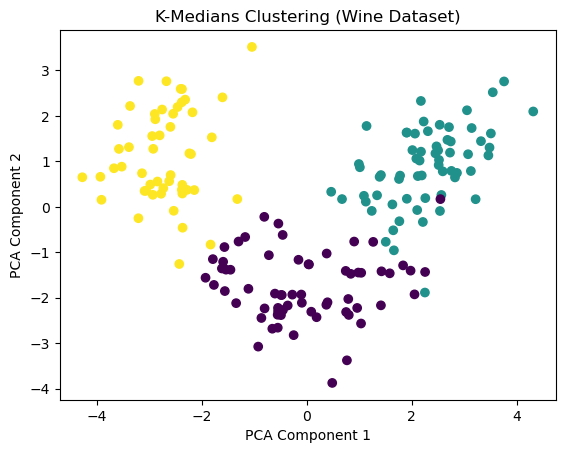

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
data = pd.read_csv("wine-clustering.csv")

# Convert to numpy array
X = data.values

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Number of clusters
k = 3

# Initialize centers randomly
np.random.seed(42)
centers = X_scaled[np.random.choice(len(X_scaled), k, replace=False)]

for iteration in range(100):

    clusters = [[] for _ in range(k)]

    # Assign points using Manhattan distance
    for point in X_scaled:
        distances = [np.sum(np.abs(point - center)) for center in centers]
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    # Update centers using median
    new_centers = np.array([np.median(cluster, axis=0) for cluster in clusters])

    if np.all(centers == new_centers):
        break

    centers = new_centers

# Assign cluster labels
labels = []
for point in X_scaled:
    distances = [np.sum(np.abs(point - center)) for center in centers]
    labels.append(np.argmin(distances))

labels = np.array(labels)

# Add cluster column to dataset
data["Cluster"] = labels

print(data.head())

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("K-Medians Clustering (Wine Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()